<a href="https://colab.research.google.com/github/elfika03/my-colab-notebooks/blob/main/praktikum_klasifikasi_buah_cnn_v2_pisang_real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Big Data Analitik
## Klasifikasi Citra Buah Apel, Pisang, dan Jeruk Menggunakan CNN

Versi perbaikan dataset pisang agar bentuk pisang lebih utuh dan realistis.

**Catatan penting:** sebelum menjalankan versi ini, pilih **Runtime > Restart runtime**, lalu jalankan dari awal. Kode ini memakai folder baru `/content/dataset_buah_v2`, sehingga dataset lama tidak tercampur.

In [ ]:
# ==========================================================
# PRAKTIKUM BIG DATA ANALITIK
# Klasifikasi Citra Buah Apel, Pisang, dan Jeruk Menggunakan CNN
# Versi Perbaikan: Dataset pisang dibuat lebih realistis
# Platform: Google Colab
# ==========================================================

import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter
import tensorflow as tf
from tensorflow.keras import layers, models

# Agar hasil percobaan lebih konsisten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

# ==========================================================

TensorFlow version: 2.20.0


## 1. MEMBUAT DATASET CITRA BUAH SECARA OTOMATIS

In [ ]:
# 1. MEMBUAT DATASET CITRA BUAH SECARA OTOMATIS
# ==========================================================
# Catatan:
# Pada versi lama, bentuk pisang terlalu sederhana dan terlihat seperti potongan.
# Pada versi ini, pisang dibuat lebih utuh, melengkung, memiliki ujung cokelat,
# bayangan, tekstur, dan variasi posisi agar lebih mirip pisang asli.

IMG_SIZE = 160
JUMLAH_GAMBAR_PER_KELAS = 200
BASE_DIR = "/content/dataset_buah_v2"
KELAS_BUAH = ["apel", "pisang", "jeruk"]

# Hapus dataset lama agar tidak tercampur dengan dataset versi sebelumnya
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

for nama_kelas in KELAS_BUAH:
    os.makedirs(os.path.join(BASE_DIR, nama_kelas), exist_ok=True)


def tambah_noise(img, level=5):
    """Menambahkan sedikit noise agar gambar tidak terlalu polos."""
    arr = np.array(img).astype(np.int16)
    noise = np.random.randint(-level, level + 1, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def buat_background():
    """Membuat latar belakang terang seperti foto buah di meja/kertas."""
    warna = tuple(np.random.randint(238, 256, size=3).tolist())
    img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), warna)
    draw = ImageDraw.Draw(img)

    # Tambahkan variasi gradasi ringan agar tidak terlalu flat
    for y in range(IMG_SIZE):
        tambahan = int((y / IMG_SIZE) * random.randint(0, 12))
        r = min(255, warna[0] + tambahan)
        g = min(255, warna[1] + tambahan)
        b = min(255, warna[2] + tambahan)
        draw.line((0, y, IMG_SIZE, y), fill=(r, g, b))

    return img


def resize_layer(layer, skala):
    """Mengubah ukuran layer transparan lalu menempatkan kembali di tengah canvas."""
    w = max(1, int(IMG_SIZE * skala))
    h = max(1, int(IMG_SIZE * skala))
    kecil = layer.resize((w, h), Image.Resampling.LANCZOS)
    canvas = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    x = (IMG_SIZE - w) // 2 + random.randint(-10, 10)
    y = (IMG_SIZE - h) // 2 + random.randint(-10, 10)
    canvas.alpha_composite(kecil, (x, y))
    return canvas


def gambar_apel():
    img = buat_background().convert("RGBA")
    layer = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer)

    x = random.randint(42, 55)
    y = random.randint(38, 52)
    w = random.randint(58, 76)
    h = random.randint(62, 80)
    warna_apel = (
        random.randint(200, 255),
        random.randint(15, 55),
        random.randint(10, 45),
        255
    )

    # Bayangan
    draw.ellipse((x + 8, y + h + 7, x + w - 4, y + h + 18), fill=(0, 0, 0, 35))

    # Bentuk apel
    draw.ellipse((x, y, x + w, y + h), fill=warna_apel, outline=(120, 0, 0, 255), width=2)
    draw.ellipse((x + 10, y + 10, x + 28, y + 30), fill=(255, 190, 185, 190))

    # Batang dan daun
    draw.rounded_rectangle((x + w//2 - 3, y - 15, x + w//2 + 4, y + 8), radius=2, fill=(100, 60, 25, 255))
    draw.ellipse((x + w//2 + 4, y - 18, x + w//2 + 30, y + 3), fill=(35, 150, 45, 255), outline=(10, 100, 25, 255))

    sudut = random.randint(-12, 12)
    skala = random.uniform(0.9, 1.08)
    layer = resize_layer(layer, skala)
    layer = layer.rotate(sudut, resample=Image.Resampling.BICUBIC, expand=False)

    img.alpha_composite(layer)
    return tambah_noise(img.convert("RGB"), level=5)


def gambar_jeruk():
    img = buat_background().convert("RGBA")
    layer = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer)

    x = random.randint(44, 56)
    y = random.randint(42, 55)
    ukuran = random.randint(60, 76)
    warna_jeruk = (255, random.randint(130, 175), random.randint(10, 35), 255)

    # Bayangan
    draw.ellipse((x + 8, y + ukuran + 8, x + ukuran - 4, y + ukuran + 20), fill=(0, 0, 0, 35))

    # Bentuk jeruk
    draw.ellipse((x, y, x + ukuran, y + ukuran), fill=warna_jeruk, outline=(180, 90, 0, 255), width=2)

    # Tekstur pori jeruk
    for _ in range(45):
        px = random.randint(x + 8, x + ukuran - 8)
        py = random.randint(y + 8, y + ukuran - 8)
        # Pastikan titik masih berada dalam lingkaran
        cx = x + ukuran / 2
        cy = y + ukuran / 2
        if (px - cx) ** 2 + (py - cy) ** 2 < (ukuran / 2 - 5) ** 2:
            draw.ellipse((px, py, px + 1, py + 1), fill=(230, 110, 0, 180))

    draw.ellipse((x + 14, y + 12, x + 33, y + 31), fill=(255, 220, 130, 170))

    sudut = random.randint(-8, 8)
    skala = random.uniform(0.92, 1.08)
    layer = resize_layer(layer, skala)
    layer = layer.rotate(sudut, resample=Image.Resampling.BICUBIC, expand=False)

    img.alpha_composite(layer)
    return tambah_noise(img.convert("RGB"), level=5)


def catmull_rom_chain(points, samples_per_seg=18):
    """Membuat titik kurva halus dari beberapa titik kontrol."""
    hasil = []
    P = [points[0]] + points + [points[-1]]
    for i in range(1, len(P) - 2):
        p0 = np.array(P[i - 1], dtype=float)
        p1 = np.array(P[i], dtype=float)
        p2 = np.array(P[i + 1], dtype=float)
        p3 = np.array(P[i + 2], dtype=float)

        for j in range(samples_per_seg):
            t = j / samples_per_seg
            t2 = t * t
            t3 = t2 * t
            titik = 0.5 * (
                (2 * p1)
                + (-p0 + p2) * t
                + (2 * p0 - 5 * p1 + 4 * p2 - p3) * t2
                + (-p0 + 3 * p1 - 3 * p2 + p3) * t3
            )
            hasil.append(tuple(titik))
    hasil.append(points[-1])
    return hasil


def gambar_pisang():
    """Membuat gambar pisang yang lebih utuh dan lebih mirip pisang asli."""
    img = buat_background().convert("RGBA")

    # Pakai canvas besar agar tepi pisang lebih halus saat diperkecil
    scale = 4
    S = IMG_SIZE * scale
    layer_besar = Image.new("RGBA", (S, S), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer_besar)

    # Titik kontrol untuk bentuk pisang melengkung.
    # Bentuk ini lebih mirip pisang utuh daripada versi lama yang terlihat seperti potongan.
    titik_kontrol = [
        (30, 95),
        (45, 110),
        (75, 114),
        (105, 96),
        (130, 60)
    ]

    # Variasi posisi titik agar dataset tidak identik semua
    titik_kontrol = [
        ((x + random.randint(-4, 4)) * scale, (y + random.randint(-4, 4)) * scale)
        for x, y in titik_kontrol
    ]
    kurva = catmull_rom_chain(titik_kontrol, samples_per_seg=18)

    warna_pisang = (
        random.randint(240, 255),
        random.randint(212, 238),
        random.randint(35, 75),
        255
    )
    warna_pinggir = (165, 115, 18, 255)
    warna_ujung = (90, 55, 20, 255)

    # Bayangan
    bayangan = [(x + 8 * scale, y + 8 * scale) for x, y in kurva]
    draw.line(bayangan, fill=(0, 0, 0, 40), width=36 * scale, joint="curve")

    # Outline dan badan pisang
    draw.line(kurva, fill=warna_pinggir, width=34 * scale, joint="curve")
    draw.line(kurva, fill=warna_pisang, width=28 * scale, joint="curve")

    # Garis highlight agar pisang tidak terlihat datar
    highlight = [(x - 2 * scale, y - 8 * scale) for x, y in kurva[5:-5]]
    draw.line(highlight, fill=(255, 248, 135, 170), width=4 * scale, joint="curve")

    # Garis sisi pisang
    garis_sisi = [(x + 2 * scale, y + 5 * scale) for x, y in kurva[5:-5]]
    draw.line(garis_sisi, fill=(195, 140, 30, 160), width=2 * scale, joint="curve")

    # Ujung pisang dibuat menempel pada badan pisang
    radius = 6 * scale
    for x, y in [kurva[0], kurva[-1]]:
        draw.ellipse((x - radius, y - radius, x + radius, y + radius), fill=warna_ujung)

    # Bintik kecil pada kulit pisang
    for _ in range(random.randint(8, 18)):
        idx = random.randint(5, len(kurva) - 6)
        x, y = kurva[idx]
        x += random.randint(-9, 9) * scale
        y += random.randint(-8, 8) * scale
        draw.ellipse((x, y, x + 1.5 * scale, y + 1.5 * scale), fill=(120, 75, 20, 95))

    layer_besar = layer_besar.filter(ImageFilter.GaussianBlur(radius=0.35 * scale))
    layer = layer_besar.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

    # Variasi rotasi dan ukuran agar model lebih kuat saat diuji gambar asli
    sudut = random.randint(-25, 25)
    skala = random.uniform(0.86, 1.12)
    layer = resize_layer(layer, skala)
    layer = layer.rotate(sudut, resample=Image.Resampling.BICUBIC, expand=False)

    img.alpha_composite(layer)
    return tambah_noise(img.convert("RGB"), level=5)

fungsi_gambar = {
    "apel": gambar_apel,
    "pisang": gambar_pisang,
    "jeruk": gambar_jeruk
}

for nama_kelas in KELAS_BUAH:
    for i in range(JUMLAH_GAMBAR_PER_KELAS):
        img = fungsi_gambar[nama_kelas]()
        path = os.path.join(BASE_DIR, nama_kelas, f"{nama_kelas}_{i:03d}.png")
        img.save(path)

print("Dataset berhasil dibuat di:", BASE_DIR)
print("Jumlah kelas:", len(KELAS_BUAH))
print("Jumlah gambar per kelas:", JUMLAH_GAMBAR_PER_KELAS)
print("Jumlah total gambar:", len(KELAS_BUAH) * JUMLAH_GAMBAR_PER_KELAS)

# ==========================================================

Dataset berhasil dibuat di: /content/dataset_buah_v2
Jumlah kelas: 3
Jumlah gambar per kelas: 200
Jumlah total gambar: 600


## 2. MENAMPILKAN CONTOH CITRA DATASET

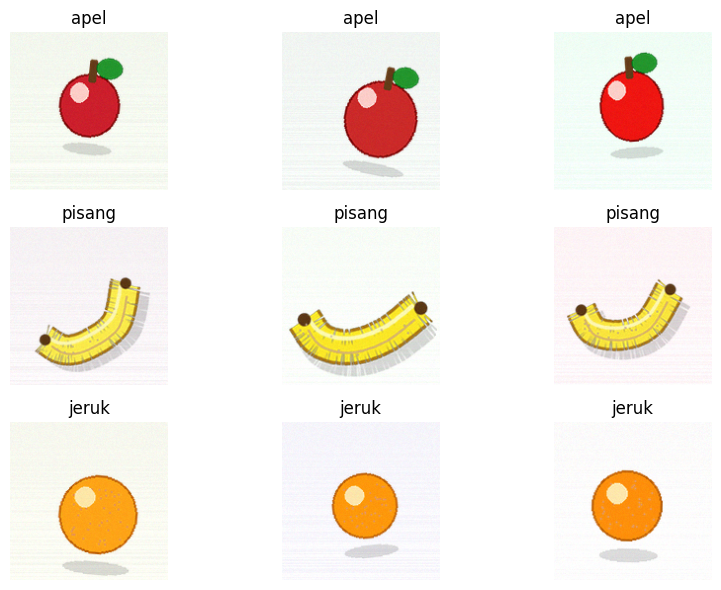

In [ ]:
# 2. MENAMPILKAN CONTOH CITRA DATASET
# ==========================================================

plt.figure(figsize=(9, 6))
nomor = 1

for nama_kelas in KELAS_BUAH:
    folder = os.path.join(BASE_DIR, nama_kelas)
    contoh_file = random.sample(os.listdir(folder), 3)

    for file in contoh_file:
        img_path = os.path.join(folder, file)
        img = Image.open(img_path)
        plt.subplot(3, 3, nomor)
        plt.imshow(img)
        plt.title(nama_kelas)
        plt.axis("off")
        nomor += 1

plt.tight_layout()
plt.show()

# ==========================================================

## 3. MEMBAGI DATASET MENJADI DATA TRAINING DAN VALIDASI

In [ ]:
# 3. MEMBAGI DATASET MENJADI DATA TRAINING DAN VALIDASI
# ==========================================================

BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Nama kelas:", class_names)

# Optimasi pembacaan data agar training lebih cepat
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(600).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================================

Found 600 files belonging to 3 classes.
Using 480 files for training.
Found 600 files belonging to 3 classes.
Using 120 files for validation.
Nama kelas: ['apel', 'jeruk', 'pisang']


## 4. MEMBUAT MODEL CNN SEDERHANA

In [ ]:
# 4. MEMBUAT MODEL CNN SEDERHANA
# ==========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.12)
])

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.35),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==========================================================

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,283 (973.76 KB)

 Trainable params: 249,283 (973.76 KB)

 Non-trainable params: 0 (0.00 B)

## 5. MELATIH MODEL

In [ ]:
# 5. MELATIH MODEL
# ==========================================================

EPOCHS = 15

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# ==========================================================

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4958 - loss: 1.0296 - val_accuracy: 0.6583 - val_loss: 0.6732
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8625 - loss: 0.3419 - val_accuracy: 0.9333 - val_loss: 0.1251
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9750 - loss: 0.0840 - val_accuracy: 1.0000 - val_loss: 0.0332
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9854 - loss: 0.0429 - val_accuracy: 1.0000 - val_loss: 0.0058
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9854 - loss: 0.0404 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 5.2876e-04
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 1.1473e-04


## 6. MENAMPILKAN GRAFIK AKURASI DAN LOSS

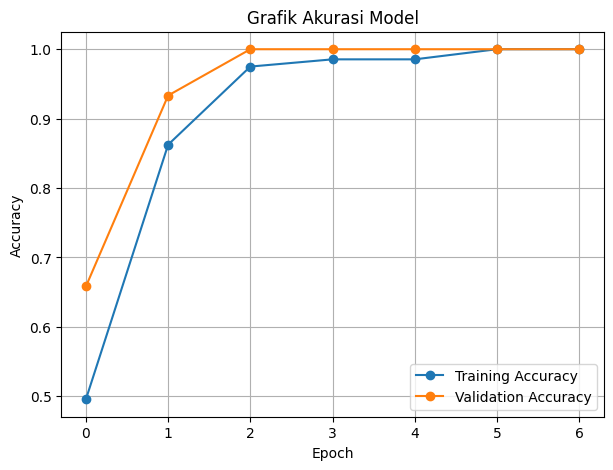

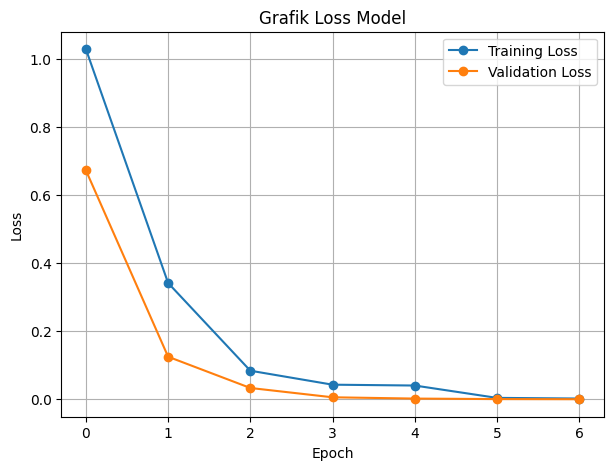

In [ ]:
# 6. MENAMPILKAN GRAFIK AKURASI DAN LOSS
# ==========================================================

plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Grafik Akurasi Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Grafik Loss Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================

## 7. EVALUASI MODEL

In [ ]:
# 7. EVALUASI MODEL
# ==========================================================

loss, accuracy = model.evaluate(val_ds)
print("Validation Loss:", round(loss, 4))
print("Validation Accuracy:", round(accuracy, 4))

# ==========================================================

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 1.0000 - loss: 0.0332
Validation Loss: 0.0332
Validation Accuracy: 1.0


## 8. MEMBUAT CONFUSION MATRIX

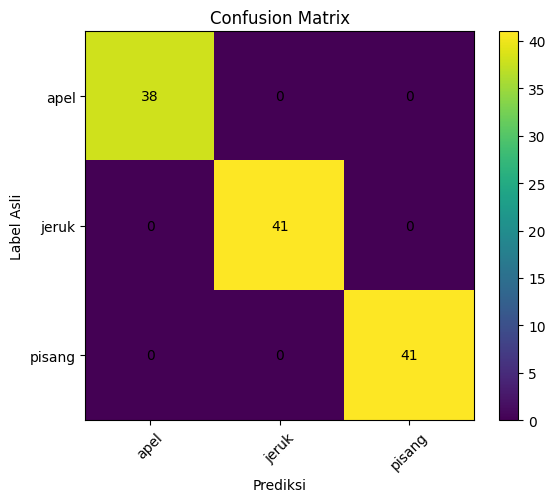

In [ ]:
# 8. MEMBUAT CONFUSION MATRIX
# ==========================================================

y_true = []
y_pred = []

for gambar, label in val_ds:
    prediksi = model.predict(gambar, verbose=0)
    y_true.extend(label.numpy())
    y_pred.extend(np.argmax(prediksi, axis=1))

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Label Asli")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# ==========================================================

## 9. PREDIKSI SATU GAMBAR

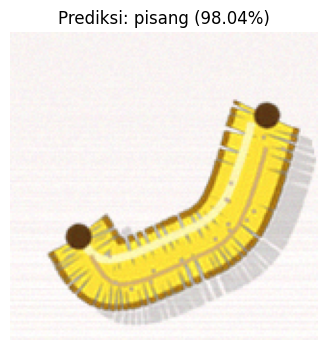

File gambar: /content/dataset_buah_v2/pisang/pisang_001.png
Hasil prediksi: pisang
Confidence: 98.04%
Skor semua kelas:
- apel: 0.01%
- jeruk: 1.95%
- pisang: 98.04%


In [ ]:
# 9. PREDIKSI SATU GAMBAR
# ==========================================================
# Perbaikan penting:
# Pada model sudah ada Dense(..., activation="softmax").
# Jadi hasil model.predict() sudah berupa probabilitas.
# Jangan diberi tf.nn.softmax lagi, karena bisa membuat nilai confidence menjadi salah.


def prediksi_gambar(gambar_path):
    img = tf.keras.utils.load_img(gambar_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    skor = model.predict(img_array, verbose=0)[0]

    index_tertinggi = int(np.argmax(skor))
    label_prediksi = class_names[index_tertinggi]
    confidence = 100 * float(np.max(skor))

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {label_prediksi} ({confidence:.2f}%)")
    plt.show()

    print("File gambar:", gambar_path)
    print("Hasil prediksi:", label_prediksi)
    print("Confidence:", f"{confidence:.2f}%")

    # Menampilkan semua skor kelas agar mahasiswa bisa melihat perbandingan
    print("Skor semua kelas:")
    for nama_kelas, nilai in zip(class_names, skor):
        print(f"- {nama_kelas}: {nilai * 100:.2f}%")

# Contoh uji menggunakan salah satu gambar dari dataset
contoh_path = os.path.join(BASE_DIR, "pisang", "pisang_001.png")
prediksi_gambar(contoh_path)

# ==========================================================

## 10. OPSIONAL: UPLOAD GAMBAR DARI KOMPUTER MAHASISWA

Saving Screenshot 2026-06-18 120959.png to Screenshot 2026-06-18 120959.png


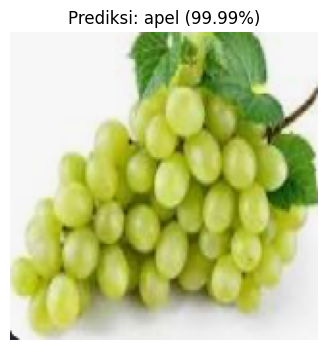

File gambar: Screenshot 2026-06-18 120959.png
Hasil prediksi: apel
Confidence: 99.99%
Skor semua kelas:
- apel: 99.99%
- jeruk: 0.01%
- pisang: 0.00%


In [ ]:
# 10. OPSIONAL: UPLOAD GAMBAR DARI KOMPUTER MAHASISWA
# ==========================================================
# Jalankan cell ini jika ingin menguji gambar buah dari komputer.
# Tips: pakai gambar yang jelas, 1 buah saja, latar tidak terlalu ramai.

from google.colab import files

uploaded = files.upload()

for nama_file in uploaded.keys():
    prediksi_gambar(nama_file)

# ==========================================================

## 11. MENYIMPAN MODEL

In [ ]:
# 11. MENYIMPAN MODEL
# ==========================================================

model.save("/content/model_klasifikasi_buah_cnn_v2.keras")
print("Model berhasil disimpan: /content/model_klasifikasi_buah_cnn_v2.keras")

Model berhasil disimpan: /content/model_klasifikasi_buah_cnn_v2.keras
